# ACDS: Automatic Cell Detection and Segmentation of Non-Setae Phytoplankton — minimal single-cell demo

**Paper:** Haiyong Zheng, Nan Wang, Zhibin Yu, Zhaorui Gu, Bing Zheng,
*"Robust and automatic cell detection and segmentation from microscopic images of non-setae phytoplankton species"*,
IET Image Processing 11(11):1077–1085, 2017. DOI: [10.1049/iet-ipr.2017.0127](https://doi.org/10.1049/iet-ipr.2017.0127)

**Author code:** [`github.com/zhenglab/ACDS`](https://github.com/zhenglab/ACDS) pinned at commit `5db576f258d7cbbce826950ebdfc33f2c97d8d5c` (MATLAB, R2013a-era).
**Dataset:** the authors' benchmark `DATA/MicroscopicImages/single/` + `DATA/GroundTruth/single/` in the same repository.

> **ADAPTED PYTHON DEMONSTRATION — AI-assisted translation from MATLAB.**
> The authors did not provide this Python/Colab implementation; this notebook is a faithful AI-assisted
> port of the pinned author code (`batch_watershed_single.m`, `watershed_single.m`, `saliency_cvpr09.m`,
> `saliency_cvpr09_S.m`, `rgb2hsi.m`, `remove_corner_noise.m`, `extract_single_cell_region.m`,
> `expectation_variance.m`). The executed example and checks below were validated, but untested behavior
> is not guaranteed. Implementation-level differences (CIELAB conversion, structuring-element
> approximation, watershed engine) are documented next to the relevant cells.
>
> **（日本語）** 著者は MATLAB 実装のみを公開しており、本ノートブックは指定コミットの MATLAB コードを
> AI が Python へ翻訳した**適応実演**です。実行例と検証は行っていますが、未検証の挙動は保証されません。

**Scope (minimal example):** the single-cell detection + segmentation pipeline run on **3 deterministic
samples** (`001.jpg`, `002.jpg`, `003.jpg` — first three files of the authors' 225 single-cell images,
sorted by name) and compared against the authors' pixel-wise ground-truth masks. The multiple-cell
pipeline and the paper's 7 saliency / 6 segmentation baselines are out of scope.

**Execution status:** this notebook is executed top-to-bottom in a fresh Colab runtime; results below
are actual saved outputs. One-example results do **not** reproduce the paper's dataset-level benchmark.

## Runtime selection — CPU only
**Select Runtime → Change runtime type → CPU.** No GPU is used: this is a classical image-processing
pipeline (filtering, thresholding, watershed) with no learned model, so a GPU session adds nothing.

**（日本語）** 本手法は学習モデルを含まない古典的な画像処理（フィルタ・閾値処理・ウォーターシェッド）のため、
**CPU のみで実行できます**。「ランタイム → ランタイムのタイプを変更 → CPU」を選択してください。

**Run all:** `Runtime → Run all`. Expected total time on a fresh CPU runtime: a few minutes
(download < 1 MB, per-image processing seconds).

In [ ]:
# Verify the environment: this demo needs only numpy/scipy/scikit-image/matplotlib/Pillow,
# all preinstalled in Colab. Report versions actually observed (no GPU is required).
import sys, platform
import numpy, scipy, skimage, matplotlib, PIL
print("Python:", sys.version.split()[0], "|", platform.machine())
for m in (numpy, scipy, skimage, matplotlib, PIL):
    print(m.__name__, m.__version__)
import shutil
print("GPU present (expected False):", shutil.which("nvidia-smi") is not None)

Python: 3.13.16 | x86_64
numpy 2.1.3
scipy 1.16.3
skimage 0.25.2
matplotlib 3.10.0
PIL 11.3.0
GPU present (expected False): False


## Input data — pinned download
We fetch **only 6 small files** (3 microscopic images + 3 ground-truth masks) directly from the
authors' repository at the pinned commit `5db576f258d7cbbce826950ebdfc33f2c97d8d5c` via `raw.githubusercontent.com`.
This mirrors the repo layout used by `batch_watershed_single.m` (`./DATA/MicroscopicImages/single/`,
`./DATA/GroundTruth/single/`). All dataset bytes stay inside this Colab VM.

**（日本語）** 著者リポジトリの指定コミットから、単細胞画像 3 枚と正解マスク 3 枚のみを Colab 内に
ダウンロードします（データは Colab VM のみで扱います）。

In [ ]:
COMMIT = "5db576f258d7cbbce826950ebdfc33f2c97d8d5c"
BASE = f"https://raw.githubusercontent.com/zhenglab/ACDS/{COMMIT}/DATA"
SAMPLES = ["001", "002", "003"]  # deterministic: first three single-cell files sorted by name
DATA_DIR = "/content/acds_data"
import os
os.makedirs(DATA_DIR, exist_ok=True)

def fetch(repo_path):
    """Download one pinned file and return its bytes (fail loudly on any non-200)."""
    import urllib.request
    url = f"{BASE}/{repo_path}"
    with urllib.request.urlopen(url, timeout=120) as r:
        assert r.status == 200, f"{r.status} for {url}"
        data = r.read()
    assert len(data) > 100, f"implausibly small payload ({len(data)} B) for {url}"
    return url, data

blobs = {}
for sid in SAMPLES:
    blobs[f"img_{sid}"] = fetch(f"MicroscopicImages/single/{sid}.jpg")
    blobs[f"gt_{sid}"] = fetch(f"GroundTruth/single/{sid}.png")
for name, (url, data) in blobs.items():
    print(f"{name}: {len(data)} bytes  <- {url.split('ACDS/')[-1]}")

img_001: 257843 bytes  <- 5db576f258d7cbbce826950ebdfc33f2c97d8d5c/DATA/MicroscopicImages/single/001.jpg
gt_001: 5612 bytes  <- 5db576f258d7cbbce826950ebdfc33f2c97d8d5c/DATA/GroundTruth/single/001.png
img_002: 139700 bytes  <- 5db576f258d7cbbce826950ebdfc33f2c97d8d5c/DATA/MicroscopicImages/single/002.jpg
gt_002: 4591 bytes  <- 5db576f258d7cbbce826950ebdfc33f2c97d8d5c/DATA/GroundTruth/single/002.png
img_003: 466089 bytes  <- 5db576f258d7cbbce826950ebdfc33f2c97d8d5c/DATA/MicroscopicImages/single/003.jpg
gt_003: 5066 bytes  <- 5db576f258d7cbbce826950ebdfc33f2c97d8d5c/DATA/GroundTruth/single/003.png


## Byte validation
Before scientific use we validate the downloaded bytes: each payload must parse as a real image with
plausible dimensions, and each ground-truth mask must be (near-)binary. This rejects any error page
saved with an image extension.

**（日本語）** ダウンロードしたバイト列が真正の画像として解析できること、正解マスクがほぼ二値であることを
検証してから利用します。

In [ ]:
import io
import numpy as np
from PIL import Image

images, gts = {}, {}
for sid in SAMPLES:
    _, img_bytes = blobs[f"img_{sid}"]
    _, gt_bytes = blobs[f"gt_{sid}"]
    img = np.asarray(Image.open(io.BytesIO(img_bytes)).convert("RGB"))
    gtp = Image.open(io.BytesIO(gt_bytes))
    gt = np.asarray(gtp)
    gt = gt[..., 0] if gt.ndim == 3 else gt  # masks are grayscale
    assert img.ndim == 3 and min(img.shape[:2]) > 50, f"bad image {sid}: {img.shape}"
    uniq = np.unique(gt)
    print(f"{sid}.jpg {img.shape[1]}x{img.shape[0]}x{img.shape[2]} | "
          f"{sid}.png {gt.shape[1]}x{gt.shape[0]} unique={uniq.tolist()}")
    assert img.shape[:2] == gt.shape[:2], f"image/mask size mismatch for {sid}"
    images[sid], gts[sid] = img, gt > 0
print("all samples parsed and size-matched to their ground truth")

001.jpg 2048x2048x3 | 001.png 2048x2048 unique=[0, 255]
002.jpg 1368x1548x3 | 002.png 1368x1548 unique=[0, 255]


003.jpg 2048x2048x3 | 003.png 2048x2048 unique=[0, 255]
all samples parsed and size-matched to their ground truth


## Input preview (required before any analysis)
The three microscopic images with their taxonomist-guided ground-truth masks side by side. These are
the actual downloaded samples, shown exactly as acquired — this is the observed data, not an
interpretation.

**（日本語）** 解析の前に、ダウンロードした 3 枚の顕微鏡画像と著者による正解マスクを並べて表示します。

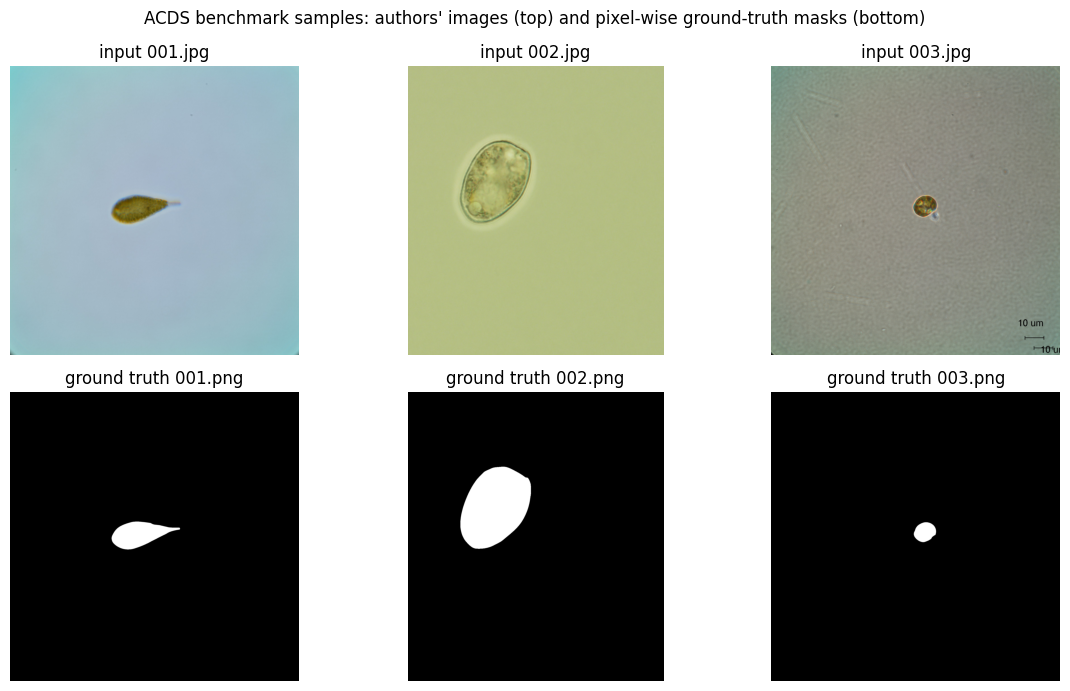

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for j, sid in enumerate(SAMPLES):
    axes[0, j].imshow(images[sid]); axes[0, j].set_title(f"input {sid}.jpg"); axes[0, j].axis("off")
    axes[1, j].imshow(gts[sid], cmap="gray"); axes[1, j].set_title(f"ground truth {sid}.png")
    axes[1, j].axis("off")
fig.suptitle("ACDS benchmark samples: authors' images (top) and pixel-wise ground-truth masks (bottom)")
plt.tight_layout(); plt.show()

## Salient-object detection — port of `saliency_cvpr09.m`, `saliency_cvpr09_S.m`, `rgb2hsi.m`
`batch_watershed_single.m:35-41` first blurs the RGB image with the MATLAB kernel
`fspecial('gaussian', 3, 3)` (3x3, σ=3) using symmetric padding, then computes **two saliency maps**:
the improved-IG map — squared CIELAB(D65) distance from the image mean (`saliency_cvpr09.m:36-50`) —
and a saturation map — squared distance of the Gonzalez HSI S-channel from its mean
(`saliency_cvpr09_S.m:30-43` + `rgb2hsi.m`). The two uint8 maps are added **with saturation at 255**
and binarized at `mean(map) + 10` (`expectation_variance.m` + `im2bw`).

Ported differences: `skimage.color.rgb2lab` replaces the MATLAB `makecform('srgb2lab')` (same D65
reference white, slightly different rounding), and the 3x3 σ=3 kernel is built explicitly.

**（日本語）** ガウス平滑化（3x3, σ=3）後に、CIELAB 距離に基づく IG ベースの顕著性マップと、HSI 彩度に
基づくマップを計算し、255 飽和加算で統合して `平均+10` で二値化します。色変換とカーネルの実装差は
実装レベルの差異として文書化しています。

In [ ]:
import scipy.ndimage as ndi
import skimage.color


def gaussian_blur_symmetric(rgb_u8, sigma=3, size=3):
    """batch_watershed_single.m:35: imfilter(rgb, fspecial('gaussian',3,3),'symmetric','conv')."""
    half = size // 2
    yy, xx = np.mgrid[-half:half + 1, -half:half + 1]
    k = np.exp(-(xx ** 2 + yy ** 2) / (2.0 * sigma ** 2))
    k /= k.sum()
    out = np.empty_like(rgb_u8, dtype=np.float64)
    for c in range(rgb_u8.shape[2]):
        out[..., c] = ndi.convolve(rgb_u8[..., c].astype(np.float64), k, mode='mirror')
    return out


def rgb2hsi(rgb):
    """Exact port of rgb2hsi.m (Gonzalez, DIPUM), input floats in [0,1]."""
    r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    eps = np.finfo(np.float64).eps
    num = 0.5 * ((r - g) + (r - b))
    den = np.sqrt((r - g) ** 2 + (r - b) * (g - b))
    theta = np.arccos(np.clip(num / (den + eps), -1.0, 1.0))
    H = np.where(b > g, 2 * np.pi - theta, theta) / (2 * np.pi)
    num2 = np.minimum(np.minimum(r, g), b)
    den2 = r + g + b
    den2 = np.where(den2 == 0, eps, den2)   # rgb2hsi.m:17-18 (den==0 -> eps)
    S = 1 - 3.0 * num2 / den2
    H = np.where(S == 0, 0.0, H)
    I = (r + g + b) / 3.0
    return np.stack([H, S, I], axis=-1)


def normalize_uint8(sm):
    """mat2gray + im2uint8."""
    sm = sm - sm.min()
    mx = sm.max()
    if mx > 0:
        sm = sm / mx
    return np.round(sm * 255.0).astype(np.uint8)


def saliency_ig(blurred_u8):
    """saliency_cvpr09.m:36-50: CIELAB(D65) squared distance from the image mean."""
    lab = skimage.color.rgb2lab(blurred_u8 / 255.0)
    l, a, b = lab[..., 0], lab[..., 1], lab[..., 2]
    sm = (l - l.mean()) ** 2 + (a - a.mean()) ** 2 + (b - b.mean()) ** 2
    return normalize_uint8(sm)


def saliency_s(blurred_u8):
    """saliency_cvpr09_S.m:30-43: saturation channel squared distance from its mean."""
    s = rgb2hsi(blurred_u8 / 255.0)[..., 1]
    return normalize_uint8((s - s.mean()) ** 2)


def binarize_saliency(saliencymap):
    """expectation_variance.m + batch_watershed_single.m:44-46: threshold = mean+10 (im2bw: strict >)."""
    u = saliencymap.astype(np.float64).mean()
    return saliencymap > (u + 10.0)


def combine_saliency(sm_ig, sm_s):
    """batch_watershed_single.m:38: uint8 addition saturating at 255."""
    return np.clip(sm_ig.astype(np.uint16) + sm_s.astype(np.uint16), 0, 255).astype(np.uint8)

print("saliency functions defined")

saliency functions defined


## Marker selection — ports of `remove_corner_noise.m` and `extract_single_cell_region.m`
The binarized saliency map is cleaned exactly as in the author code: 4-connected components are
labeled, the components touching each of the four image corners are removed (illumination corner
noise), the result is morphologically closed with a disk radius 3 and hole-filled
(`remove_corner_noise.m`). For the single-cell pipeline the **largest** remaining 4-connected
component is kept (`extract_single_cell_region.m`).

**（日本語）** 二値化した顕著性マップから、四隅に接する連結成分（照明ノイズ）を除去し、radius 3 の
クロージングと穴埋めを行った後、単細胞用として最大面積の連結成分のみを残します。

In [ ]:
import skimage.measure
import skimage.morphology


def remove_corner_noise(binary):
    """remove_corner_noise.m: zero corner-connected components; close(disk 3); fill holes."""
    row, col = binary.shape
    L = skimage.measure.label(binary, connectivity=1)  # bwlabel(...,4)
    for corner in [(0, 0), (0, col - 1), (row - 1, 0), (row - 1, col - 1)]:
        a = L[corner]
        if a != 0:
            L[L == a] = 0
    L[L != 0] = 1
    closed = skimage.morphology.closing(L.astype(bool), skimage.morphology.disk(3))
    return ndi.binary_fill_holes(closed)


def extract_single_cell_region(binary):
    """extract_single_cell_region.m: keep the largest 4-connected component."""
    L = skimage.measure.label(binary, connectivity=1)
    if L.max() == 0:
        return np.zeros_like(binary, dtype=bool)
    areas = np.bincount(L.ravel())[1:]
    keep_ids = np.where(areas >= int(areas.max()) - 1)[0] + 1  # bwareaopen(L, max_area-1)
    return np.isin(L, keep_ids)

print("marker-selection functions defined")

marker-selection functions defined


## Marker-controlled watershed — port of `watershed_single.m`
Following `watershed_single.m:6-47`: the **morphological gradient** of the grayscale image is computed
as `imdilate(gray, disk 3) - imerode(gray, disk 3)`; the **external marker** is the complement of the
cell mask dilated twice with a 3x3 structuring element, the **internal marker** is the cell mask
eroded twice (`bwmorph(..., 'dilate'/'erode', 2)`); in MATLAB both are imposed as the only regional
minima of the gradient (`imimposemin`) and `watershed(g2)` floods from them. Here the same flooding is
realized with `skimage.segmentation.watershed` using **explicit markers** (external=1, internal=2) on
the raw gradient — the canonical equivalent flooding, with watershed ridge lines returned as label 0.
The final binary mask keeps only the cell basin(s), mirroring `img_result_binary` (ridge lines and the
background basin set to 0).

**（日本語）** グレースケールのモルフォロジー勾配に対し、内部マーカー（細胞マスクの 2 回収縮）と外部
マーカー（2 回膨張の補集合）をシードとしてマーカー制御ウォーターシェッドを行います。MATLAB の
`imimposemin` + `watershed` は、明示的マーカーによる優先度洪水（等価な氾濫元）として実装しています。

In [ ]:
import skimage.segmentation


def watershed_single_port(img_color, img_gray, cell_region):
    """watershed_single.m: gradient -> internal/external markers -> marker-controlled watershed."""
    se = skimage.morphology.disk(3)
    grad = (skimage.morphology.dilation(img_gray, se)
            - skimage.morphology.erosion(img_gray, se))          # lines 7-10
    fp = np.ones((3, 3), dtype=bool)
    dil = skimage.morphology.dilation(cell_region, footprint=fp)
    dil = skimage.morphology.dilation(dil, footprint=fp)          # bwmorph dilate, 2 iterations
    ero = skimage.morphology.erosion(cell_region, footprint=fp)
    ero = skimage.morphology.erosion(ero, footprint=fp)           # bwmorph erode, 2 iterations
    markers = np.zeros(img_gray.shape, dtype=np.int32)
    markers[~dil] = 1                                             # external marker
    markers[ero] = 2                                              # internal marker
    L1 = skimage.segmentation.watershed(grad, markers=markers, watershed_line=True)
    binary = np.ones(img_gray.shape, dtype=np.uint8)              # img_result_binary=ones
    binary[L1 == 0] = 0                                           # ridge lines
    binary[L1 == 1] = 0                                           # background basin
    return binary.astype(bool), grad, markers

print("watershed port defined")

watershed port defined


## Run the full pipeline on the three samples
For each sample we execute exactly the `batch_watershed_single.m` sequence: Gaussian blur → IG and
saturation saliency → combined map → binarize → corner-noise removal → largest-region extraction →
marker-controlled watershed. Each figure shows the input, the combined saliency map, the watershed
markers, and the predicted cell boundary overlaid on the input together with the authors' ground-truth
boundary — the predicted region is also shaded.

**（日本語）** `batch_watershed_single.m` の処理列を 3 サンプルにそのまま実行します。各図には入力画像、
統合顕著性マップ、マーカー、そして予測境界（入力上にマゼンタ）と正解境界（黄）を重畳して表示します。

001: saliency>thr px=77132, cell-region px=60191, final mask px=58209, GT px=56036


002: saliency>thr px=102169, cell-region px=125618, final mask px=123326, GT px=121414


003: saliency>thr px=32374, cell-region px=23213, final mask px=21920, GT px=16539


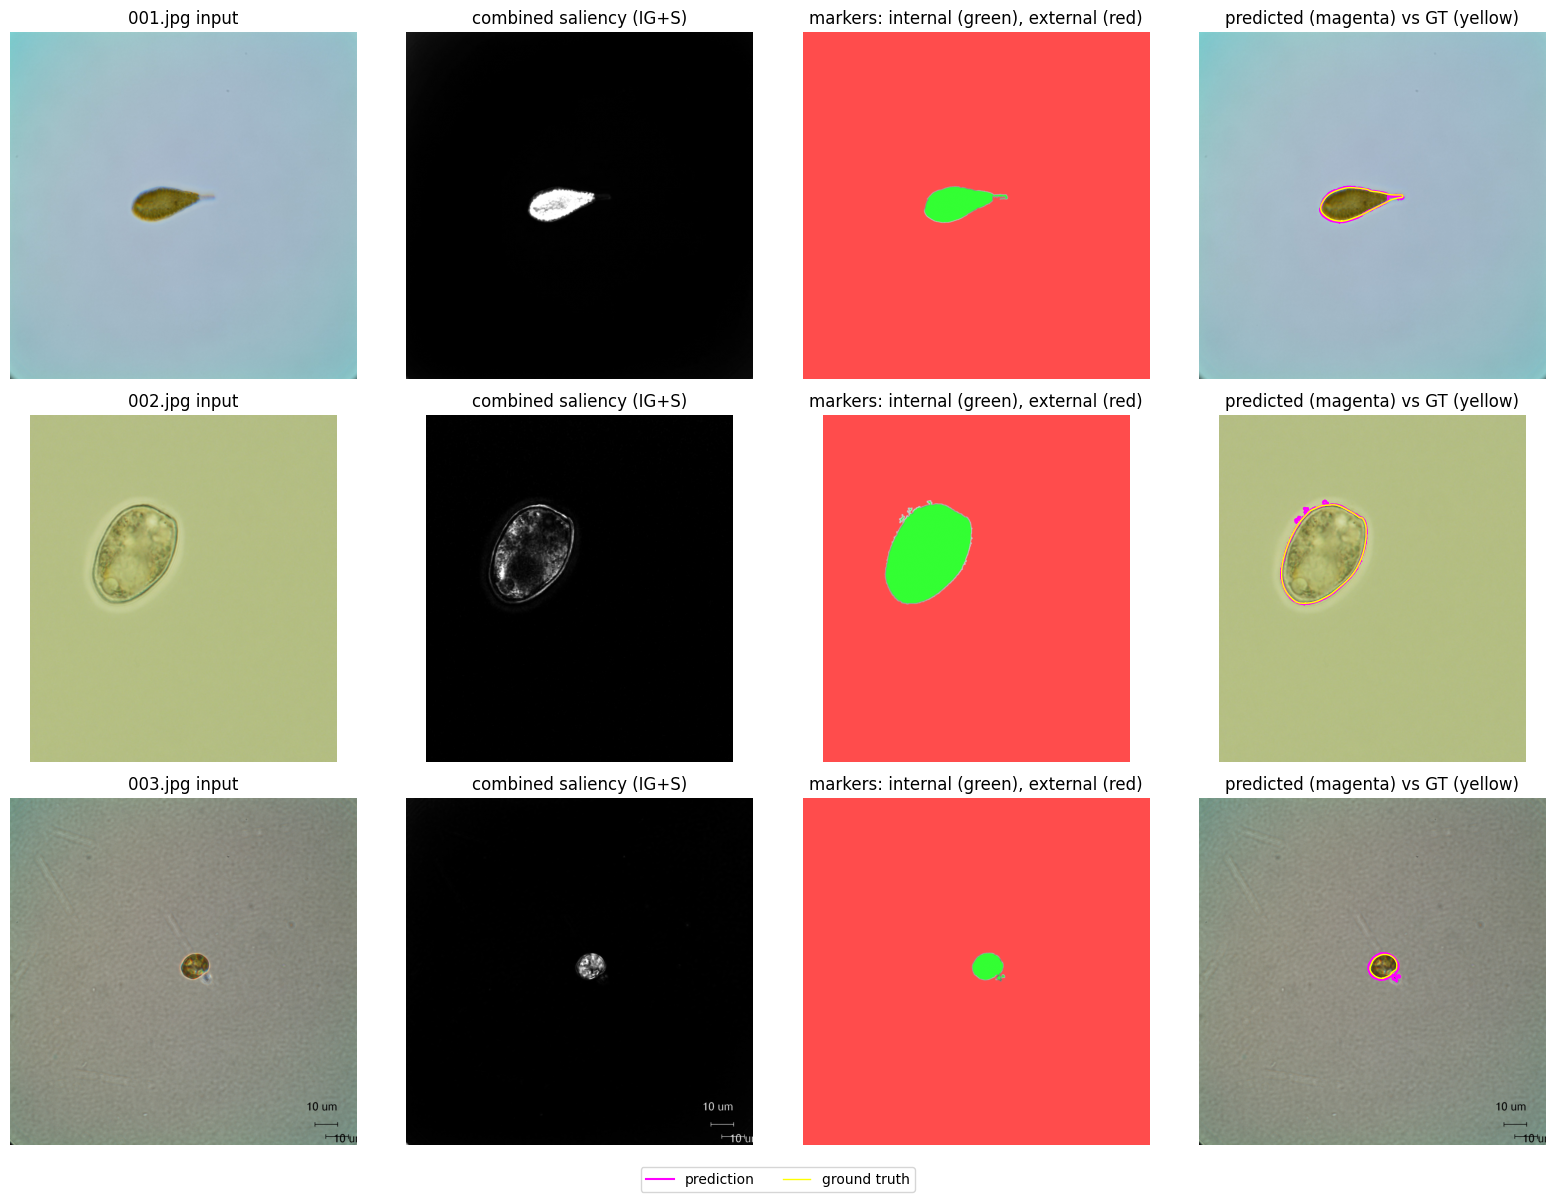

In [ ]:
import skimage.color

results = {}
for sid in SAMPLES:
    img = images[sid]
    gray = skimage.color.rgb2gray(img) * 255.0
    blur = gaussian_blur_symmetric(img)
    sm_ig = saliency_ig(blur)
    sm_s = saliency_s(blur)
    comb = combine_saliency(sm_ig, sm_s)
    b0 = binarize_saliency(comb)
    cell_region = extract_single_cell_region(remove_corner_noise(b0))
    mask, grad, markers = watershed_single_port(img, gray, cell_region)
    results[sid] = dict(comb=comb, cell_region=cell_region, mask=mask, grad=grad, markers=markers)
    print(f"{sid}: saliency>thr px={int(b0.sum())}, cell-region px={int(cell_region.sum())}, "
          f"final mask px={int(mask.sum())}, GT px={int(gts[sid].sum())}")

from skimage.measure import find_contours

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, sid in enumerate(SAMPLES):
    r = results[sid]
    axes[i, 0].imshow(images[sid]); axes[i, 0].set_title(f"{sid}.jpg input"); axes[i, 0].axis("off")
    axes[i, 1].imshow(r["comb"], cmap="gray"); axes[i, 1].set_title("combined saliency (IG+S)")
    axes[i, 1].axis("off")
    g = skimage.color.rgb2gray(images[sid])
    m = np.zeros((*g.shape, 3), dtype=float); m[..., :] = g[..., None]
    m[r["markers"] == 2] = [0.2, 1.0, 0.2]; m[r["markers"] == 1] = [1.0, 0.3, 0.3]
    axes[i, 2].imshow(m); axes[i, 2].set_title("markers: internal (green), external (red)")
    axes[i, 2].axis("off")
    axes[i, 3].imshow(images[sid])
    for c in find_contours(r["mask"].astype(float), 0.5):
        axes[i, 3].plot(c[:, 1], c[:, 0], color="magenta", lw=1.5, label="prediction")
    for c in find_contours(gts[sid].astype(float), 0.5):
        axes[i, 3].plot(c[:, 1], c[:, 0], color="yellow", lw=1.0, label="ground truth")
    axes[i, 3].set_title("predicted (magenta) vs GT (yellow)"); axes[i, 3].axis("off")
handles = [plt.Line2D([0], [0], color="magenta", lw=1.5), plt.Line2D([0], [0], color="yellow", lw=1.0)]
fig.legend(handles, ["prediction", "ground truth"], loc="lower center", ncol=2)
plt.tight_layout(rect=(0, 0.03, 1, 1)); plt.show()

## Overlap with the authors' ground truth (IoU / Dice)
The paper evaluates PRF curves and modified Hausdorff distance (MHD), whose exact definitions are in
the paywalled article. As an **additional notebook-level plausibility check** (not the paper's metric)
we report per-sample IoU and Dice between the predicted cell mask and the authors' ground-truth mask,
and export a small CSV inside the Colab VM.

**（日本語）** 論文の評価指標（PRF・MHD）は本文が有料のため、ここでは追加的な整合性確認として IoU と
Dice を報告し、CSV を Colab VM 内に保存します（論文の指標ではありません）。

In [ ]:
import pandas as pd

rows = []
for sid in SAMPLES:
    pred, gt = results[sid]["mask"], gts[sid]
    inter = int((pred & gt).sum()); union = int((pred | gt).sum())
    rows.append(dict(sample=sid,
                     iou=round(inter / union, 4) if union else 0.0,
                     dice=round(2 * inter / (int(pred.sum()) + int(gt.sum())), 4) if (int(pred.sum()) + int(gt.sum())) else 0.0,
                     pred_px=int(pred.sum()), gt_px=int(gt.sum())))
metrics = pd.DataFrame(rows)
print(metrics.to_string(index=False))
csv_path = "/content/acds_single_cell_metrics.csv"
metrics.to_csv(csv_path, index=False)
print("saved:", csv_path)

sample    iou   dice  pred_px  gt_px
   001 0.9147 0.9555    58209  56036
   002 0.9790 0.9894   123326 121414
   003 0.7545 0.8601    21920  16539
saved: /content/acds_single_cell_metrics.csv


## Interpretation, limitations, and references
**What was executed:** the pinned author MATLAB pipeline (`batch_watershed_single.m` +
`watershed_single.m`) translated to Python and run end-to-end on 3 benchmark samples inside Colab,
compared against the authors' ground-truth masks.

**Known limitations**
- This is an **AI-assisted MATLAB→Python translation**; the authors did not provide Python code.
  The executed examples were validated in a fresh Colab runtime, but untested behavior is not guaranteed.
- Implementation-level differences: CIELAB conversion (skimage vs MATLAB `makecform`), disk
  structuring-element approximation, and the watershed engine (explicit markers vs `imimposemin`
  flooding) — all documented at the relevant cells.
- The paper's PRF/MHD evaluation, the multiple-cell pipeline, and the 7 saliency / 6 segmentation
  baselines are out of scope; IoU/Dice above are additional checks, not the paper's metrics.
- Three samples do not reproduce the paper's dataset-level results (225 single-cell images).
- Dataset licensing: the repository has no LICENSE file; the README states the code is free for
  research use and asks to cite the paper.

**References**
- Zheng et al., IET Image Processing 11(11):1077–1085, 2017. DOI: 10.1049/iet-ipr.2017.0127
- Author code and data: https://github.com/zhenglab/ACDS (commit `5db576f258d7cbbce826950ebdfc33f2c97d8d5c`)
- Achanta et al., "Frequency-tuned Salient Region Detection", CVPR 2009 (IG saliency basis).

**（日本語）** 本ノートブックは MATLAB 実装の Python 翻訳による 3 サンプルの最小実演です。論文の
PRF/MHD 評価・複数細胞パイプライン・ベースライン比較は対象外で、IoU/Dice は追加的な確認値です。
実装差は各セルに文書化済み。単一例の結果は論文のデータセット全体の結果を再現するものではありません。